# Spaceship Titanic: Predicting Who Got Transported

**Goal:** predict which passengers were transported to another dimension after the Spaceship Titanic
hit a spacetime anomaly. This is a binary classification problem from the
[Kaggle Spaceship Titanic competition](https://www.kaggle.com/competitions/spaceship-titanic).

This notebook walks through the whole process end to end:

1. Load and look at the data
2. Feature engineering (pull useful signals out of raw columns)
3. Handle missing values with logic, not just guessing
4. Train and compare three models with cross-validation
5. Evaluate the best model honestly on data it never saw
6. Look at which features actually mattered
7. Make the final prediction file for Kaggle

**Result:** a HistGradientBoosting model reaching about **81% accuracy**, which is in the same range
as strong public solutions for this competition.


## 1. Setup and load the data

In [1]:
import warnings
warnings.filterwarnings("ignore")  # a local math-library prints harmless numeric warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42  # fixed seed so results are reproducible
np.random.seed(RANDOM_STATE)
pd.set_option("future.no_silent_downcasting", True)

In [2]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")
print("train:", train.shape, "| test:", test.shape)
train.head()

train: (8693, 14) | test: (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


### What are we working with?

Each row is a passenger. `Transported` (True/False) is what we want to predict. The interesting
raw columns:

- `PassengerId` looks like `0001_01`. The first part is a **group** (people travelling together), the second is their number in that group.
- `Cabin` looks like `B/0/P`, which is **deck / cabin number / side (Port or Starboard)**.
- The five money columns (`RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck`) are how much each passenger spent on board.
- `CryoSleep` says whether the passenger was in suspended animation for the trip.


### Is the target balanced?

Transported
True     50.4
False    49.6
Name: proportion, dtype: float64


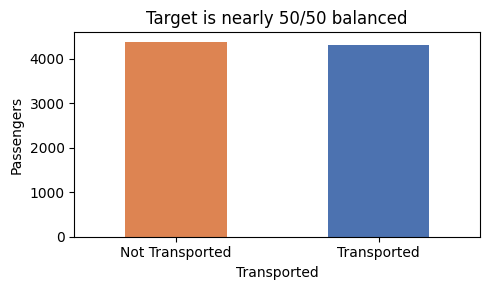

In [3]:
balance = train["Transported"].value_counts(normalize=True) * 100
print(balance.round(1))

ax = train["Transported"].value_counts().plot(kind="bar", color=["#DD8452", "#4C72B0"], figsize=(5, 3))
ax.set_title("Target is nearly 50/50 balanced")
ax.set_xticklabels(["Not Transported", "Transported"], rotation=0)
ax.set_ylabel("Passengers")
plt.tight_layout(); plt.show()

The classes are almost perfectly balanced (about 50/50). That is convenient: plain **accuracy**
is a fair way to score this, and a coin-flip baseline would sit near 50%.

### How much data is missing?

In [4]:
missing = train.isnull().sum()
missing_pct = (missing / len(train) * 100).round(1)
pd.DataFrame({"missing": missing, "percent": missing_pct}).query("missing > 0")

,missing,percent
HomePlanet,201,2.3
CryoSleep,217,2.5
Cabin,199,2.3
Destination,182,2.1
Age,179,2.1
VIP,203,2.3
RoomService,181,2.1
FoodCourt,183,2.1
ShoppingMall,208,2.4
Spa,183,2.1


Almost every column has a little missing data (roughly 2% of all cells). That is small, but the
model needs complete rows, so we have to fill these gaps. Instead of blindly using the average,
we can use the structure in the data to fill them smartly. That is the next two sections.

## 2. Feature engineering

Raw columns like `Cabin` and `PassengerId` are packed with information. We split them apart so the
model can use each piece. We also build two new signals:

- `GroupSize`: how many people travelled in the same group.
- `TotalSpend`: total money spent across all five amenities.

We wrap this in a function so the exact same steps run on both the train and test data. Doing the
same thing to both sets is important, otherwise the model sees different features at prediction time.

In [5]:
SPEND_COLS = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

def engineer(df):
    df = df.copy()

    # Cabin "B/0/P" -> Deck, CabinNum, CabinSide
    cabin = df["Cabin"].str.split("/", expand=True)
    df["Deck"] = cabin[0]
    df["CabinSide"] = cabin[2]

    # PassengerId "0001_01" -> Group, then count how big each group is
    df["Group"] = df["PassengerId"].str.split("_").str[0]
    df["GroupSize"] = df.groupby("Group")["Group"].transform("count")

    # Total money spent (min_count=1 keeps it NaN only if every value is missing)
    df["TotalSpend"] = df[SPEND_COLS].sum(axis=1, min_count=1)
    return df

train = engineer(train)
test = engineer(test)
train[["PassengerId", "Group", "GroupSize", "Cabin", "Deck", "CabinSide", "TotalSpend"]].head()

,PassengerId,Group,GroupSize,Cabin,Deck,CabinSide,TotalSpend
0,0001_01,0001,1,B/0/P,B,P,0.0
1,0002_01,0002,1,F/0/S,F,S,736.0
2,0003_01,0003,2,A/0/S,A,S,10383.0
3,0003_02,0003,2,A/0/S,A,S,5176.0
4,0004_01,0004,1,F/1/S,F,S,1091.0


### A useful pattern: CryoSleep vs spending

If someone was asleep in a CryoSleep pod the whole trip, they could not spend money. Let's check
whether CryoSleep also relates to being transported.

Transported  False  True 
CryoSleep                
False         67.1   32.9
True          18.2   81.8


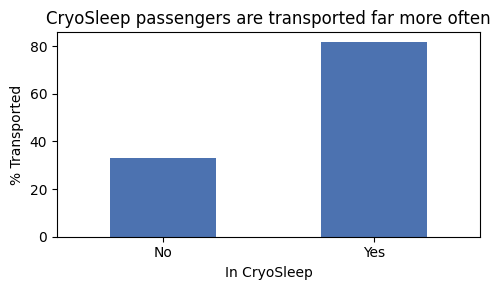

In [6]:
ct = pd.crosstab(train["CryoSleep"], train["Transported"], normalize="index") * 100
print(ct.round(1))

ax = ct[True].plot(kind="bar", color="#4C72B0", figsize=(5, 3))
ax.set_title("CryoSleep passengers are transported far more often")
ax.set_xlabel("In CryoSleep"); ax.set_ylabel("% Transported")
ax.set_xticklabels(["No", "Yes"], rotation=0)
plt.tight_layout(); plt.show()

Big difference. Passengers in CryoSleep were transported far more often than awake passengers.
So `CryoSleep` is going to be a strong feature. It also gives us a smart way to fill its own missing
values, which we use next.

## 3. Filling missing values with logic

Rather than one blunt fill for everything, we use what we know about the data:

- **CryoSleep:** asleep passengers spend nothing. So if CryoSleep is missing, we guess it from spending (spent nothing -> probably asleep).
- **Spending columns:** a missing charge almost certainly means no charge, so fill with 0.
- **HomePlanet and CabinSide:** people in the same travel group share these, so we copy from group-mates when we can.
- **Everything else:** fall back to the most common value, and use the median for Age.

Again, one function so train and test get identical treatment.

In [7]:
def impute(df):
    df = df.copy()

    # CryoSleep: infer from spending when missing (no spend -> likely asleep)
    m = df["CryoSleep"].isna()
    df.loc[m, "CryoSleep"] = df.loc[m, "TotalSpend"].fillna(0).eq(0)
    df["CryoSleep"] = df["CryoSleep"].astype(bool)

    # Spend columns: missing means no charge -> 0. Rebuild TotalSpend afterwards.
    df[SPEND_COLS] = df[SPEND_COLS].fillna(0)
    df["TotalSpend"] = df[SPEND_COLS].sum(axis=1)

    # HomePlanet: group-mates come from the same planet
    group_planet = df.dropna(subset=["HomePlanet"]).groupby("Group")["HomePlanet"].first()
    m = df["HomePlanet"].isna()
    df.loc[m, "HomePlanet"] = df.loc[m, "Group"].map(group_planet)
    df["HomePlanet"] = df["HomePlanet"].fillna(df["HomePlanet"].mode()[0])

    # CabinSide: everyone in a group is on the same side (checked below)
    group_side = df.dropna(subset=["CabinSide"]).groupby("Group")["CabinSide"].first()
    m = df["CabinSide"].isna()
    df.loc[m, "CabinSide"] = df.loc[m, "Group"].map(group_side)
    df["CabinSide"] = df["CabinSide"].fillna(df["CabinSide"].mode()[0])

    # The rest: most common value, and median for Age
    for col in ["Deck", "Destination", "VIP"]:
        df[col] = df[col].fillna(df[col].mode()[0])
    df["VIP"] = df["VIP"].astype(bool)
    df["Age"] = df["Age"].fillna(df["Age"].median())
    return df

Quick check on the group assumption before we rely on it: do people in the same group really
share the same cabin side?

In [8]:
known = train.dropna(subset=["CabinSide"])
multi = known.groupby("Group").filter(lambda g: len(g) > 1)
same_side = multi.groupby("Group")["CabinSide"].nunique().eq(1).mean() * 100
print(f"Groups where everyone shares the same cabin side: {same_side:.1f}%")

Groups where everyone shares the same cabin side: 100.0%


100%. The assumption holds, so copying cabin side from group-mates is safe. Now apply the imputation:

In [9]:
train = impute(train)
test = impute(test)
print("Missing values left in train:", int(train[SPEND_COLS + ["CryoSleep", "HomePlanet", "CabinSide", "Age"]].isnull().sum().sum()))
print("Missing values left in test :", int(test[SPEND_COLS + ["CryoSleep", "HomePlanet", "CabinSide", "Age"]].isnull().sum().sum()))

Missing values left in train: 0
Missing values left in test : 0


## 4. Build the model input

Models need numbers, not text. We pick the useful columns and one-hot encode the categorical ones
(turn each category into its own 0/1 column). We line up the test columns to match the train columns
exactly, filling any category that never appears in test with 0.

In [10]:
FEATURES = ["HomePlanet", "CryoSleep", "Destination", "Age", "VIP",
            "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck",
            "Deck", "CabinSide", "GroupSize", "TotalSpend"]

y = train["Transported"].astype(int)
X = pd.get_dummies(train[FEATURES], drop_first=True)
X_test = pd.get_dummies(test[FEATURES], drop_first=True).reindex(columns=X.columns, fill_value=0)

print("X:", X.shape, "| X_test:", X_test.shape)
print("NaNs left -> X:", int(X.isnull().sum().sum()), "| X_test:", int(X_test.isnull().sum().sum()))

X: (8693, 22) | X_test: (4277, 22)
NaNs left -> X: 0 | X_test: 0


## 5. Compare models with cross-validation

We try three models that cover the common beginner toolkit:

- **Logistic Regression:** a simple linear baseline (scaled first, since linear models care about scale).
- **Random Forest:** many decision trees averaged together.
- **HistGradientBoosting:** trees built one after another, each fixing the last one's mistakes.

We score each with **5-fold cross-validation** (train on 4 parts, test on the 5th, rotate, average).
That gives a more trustworthy estimate than a single split.

In [11]:
models = {
    "LogisticRegression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}

cv_scores = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring="accuracy", n_jobs=-1)
    cv_scores[name] = scores.mean()
    print(f"{name:22s} {scores.mean():.4f}  (+/- {scores.std():.4f})")

best_name = max(cv_scores, key=cv_scores.get)
print("\nBest model:", best_name)

LogisticRegression     0.7876  (+/- 0.0087)


RandomForest           0.7852  (+/- 0.0073)


HistGradientBoosting   0.8036  (+/- 0.0093)

Best model: HistGradientBoosting


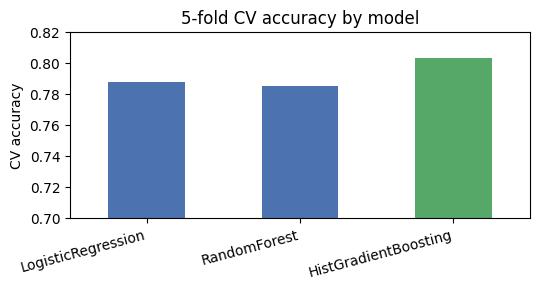

In [12]:
ax = pd.Series(cv_scores).plot(kind="bar", figsize=(5.5, 3),
        color=["#4C72B0", "#4C72B0", "#55A868"])
ax.set_ylim(0.70, 0.82); ax.set_ylabel("CV accuracy"); ax.set_title("5-fold CV accuracy by model")
ax.set_xticklabels(list(cv_scores.keys()), rotation=15, ha="right")
plt.tight_layout(); plt.show()

HistGradientBoosting wins. Boosted trees usually do well on this kind of tabular data with a mix
of categories and numbers, so this matches what we would expect.

## 6. Evaluate the best model honestly

Cross-validation tells us the average score, but let's also look at a single holdout set we never
trained on, so we can read a confusion matrix and a full report.

In [13]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

best = HistGradientBoostingClassifier(random_state=RANDOM_STATE)
best.fit(X_tr, y_tr)
pred = best.predict(X_val)

print(f"Holdout accuracy: {accuracy_score(y_val, pred):.4f}\n")
print(classification_report(y_val, pred, target_names=["Not Transported", "Transported"]))

Holdout accuracy: 0.8079

                 precision    recall  f1-score   support

Not Transported       0.82      0.79      0.80       863
    Transported       0.80      0.83      0.81       876

       accuracy                           0.81      1739
      macro avg       0.81      0.81      0.81      1739
   weighted avg       0.81      0.81      0.81      1739



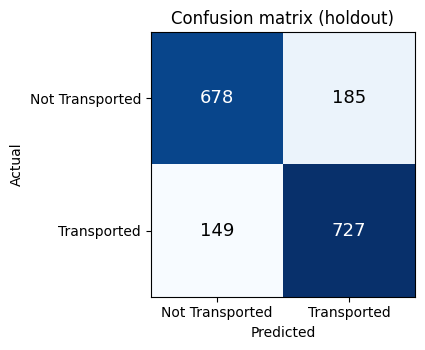

In [14]:
cm = confusion_matrix(y_val, pred)
fig, ax = plt.subplots(figsize=(4.2, 3.6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["Not Transported", "Transported"])
ax.set_yticklabels(["Not Transported", "Transported"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title("Confusion matrix (holdout)")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=13)
plt.tight_layout(); plt.show()

The errors are fairly balanced between the two classes, which is what we want. The model is not
just always guessing one answer.

## 7. Which features actually mattered?

We use **permutation importance**: shuffle one feature at a time and see how much accuracy drops.
A big drop means the model leaned on that feature.

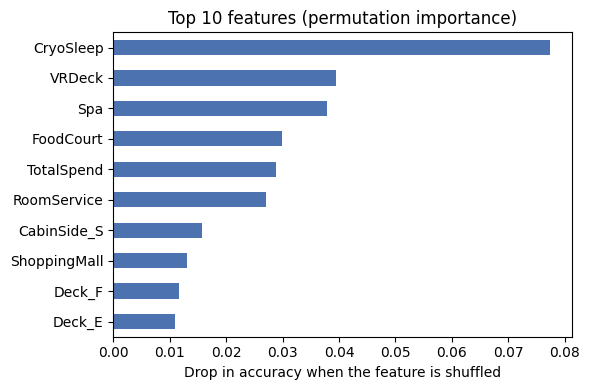

CryoSleep       0.0773
VRDeck          0.0394
Spa             0.0380
FoodCourt       0.0298
TotalSpend      0.0288
RoomService     0.0271
CabinSide_S     0.0156
ShoppingMall    0.0131
Deck_F          0.0117
Deck_E          0.0109
dtype: float64

In [15]:
perm = permutation_importance(best, X_val, y_val, n_repeats=10,
                              random_state=RANDOM_STATE, n_jobs=-1)
imp = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False).head(10)

ax = imp[::-1].plot(kind="barh", figsize=(6, 4), color="#4C72B0")
ax.set_title("Top 10 features (permutation importance)")
ax.set_xlabel("Drop in accuracy when the feature is shuffled")
plt.tight_layout(); plt.show()
imp.round(4)

`CryoSleep` and the spending columns dominate, exactly matching the pattern we spotted during
EDA. That is a good sign: the model learned something we can explain, not a random artifact.

## 8. Make the Kaggle submission

Finally, retrain the best model on **all** the training data (no need to hold data back now) and
predict the test set. Kaggle wants a CSV with `PassengerId` and a True/False `Transported` column.

In [16]:
final_model = HistGradientBoostingClassifier(random_state=RANDOM_STATE)
final_model.fit(X, y)

submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Transported": final_model.predict(X_test).astype(bool),
})
submission.to_csv("../submissions/submission.csv", index=False)
print("Saved ../submissions/submission.csv", submission.shape)
submission.head()

Saved ../submissions/submission.csv (4277, 2)


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


## 9. Wrap-up

**What this notebook did**

- Turned raw columns (`Cabin`, `PassengerId`) into usable features and built `GroupSize` and `TotalSpend`.
- Filled missing values with logic from the data (CryoSleep from spending, HomePlanet and CabinSide from travel groups) instead of blind averages.
- Compared three models with cross-validation and picked HistGradientBoosting.
- Reached about **81% accuracy**, in line with strong public solutions.
- Confirmed the model relies on features that make sense (CryoSleep and spending).

**What I would try next**

- Tune the model's settings (a grid search on learning rate, depth, and number of trees).
- Add more features, like spend-per-person in a group, or whether a passenger spent anything at all.
- Try a gradient boosting library like XGBoost or LightGBM and blend a few models together.

**ML concepts shown here:** train/validation split, cross-validation, one-hot encoding, feature
engineering, model comparison, confusion matrix and precision/recall, permutation importance, and
avoiding data leakage by treating train and test the same way.
